# Discover Probabilities

Dependencies are preinstalled on google colab

In [ ]:
import numpy as np

## State Transition Probability Matrix

For the example we study a landscape with 3 states as given in the figure


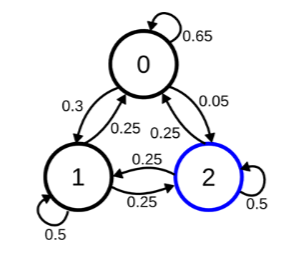

In [ ]:
# State transition probabilities matrix
T = np.array([
        [0.65, 0.3, 0.05],
        [0.25, 0.5, 0.25],
        [0.25, 0.25, 0.5]  ])

## Discovery Matrix

In [ ]:
def discoverProbabilities(T: np.ndarray, steps: int, num_sims: int = 1) -> np.ndarray:
  n_states = T.shape[0]
  discovermatrix = np.zeros((n_states, n_states))

  for state_j in range(n_states):

    nu = np.eye(n_states)
    miss_prob = 1.0 - nu[:, state_j]

    for k in range(1, steps + 1):

      if k == 1:
        nu = T.copy()
      else:
        nu[:, state_j] = 0
        sums = nu.sum(axis=1, keepdims=True)
        nu = np.divide(nu, sums, out = np.zeros_like(nu), where = sums != 0)
        nu = nu @ T

      miss_prob *= (1 - nu[:, state_j])

    discovermatrix[:, state_j] = 1 - (miss_prob ** num_sims)
    '''
    Note : The product was taken under the assumption that the parallel simulations yeilded equivalent probabilities for given example.
    In general for parallel simulations that are not necessarily equal we need to take the product from each of the simulations for the actual result using iterative calculation.
          '''

  return discovermatrix

In [ ]:
np.set_printoptions(precision=2, suppress=True)
ans = discoverProbabilities(T, 2, num_sims = 3)

In [ ]:
print(ans)

[[1.   0.88 0.4 ]
 [0.82 1.   0.77]
 [0.82 0.83 1.  ]]


> The scripts below this is for the purpose of widget simulation using the above function

### Interactive Heatmap for Discover Probabilities

This interactive widget allows you to visualize the `discoverProbabilities` matrix as a 2D heatmap. You can adjust the `steps` (number of steps in the Markov chain) and `num_sims` (number of parallel simulations) using the sliders to see how they impact the probabilities.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

def plot_discover_probabilities_heatmap(steps, num_sims):
    # Ensure num_sims is at least 1, as 0 might cause issues or not make sense
    num_sims = max(1, num_sims)

    # Call the discoverProbabilities function with the slider values
    discover_matrix = discoverProbabilities(T, steps=steps, num_sims=num_sims)

    # Create the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        discover_matrix,
        annot=True,     # Annotate cells with data values
        fmt=".2f",      # Format annotations to 2 decimal places
        cmap="viridis", # Color map
        cbar=True,      # Show color bar
        linewidths=.5,  # Lines between cells
        linecolor='black'
    )
    plt.title(f'Discover Probabilities Heatmap (Steps: {steps}, Sims: {num_sims})')
    plt.xlabel('Target State (j)')
    plt.ylabel('Initial State (i)')
    plt.show()

# Create sliders for steps and num_sims
steps_slider = widgets.IntSlider(
    min=1, max=5, step=1, value=2,
    description='Steps:',
    continuous_update=False
)

num_sims_slider = widgets.IntSlider(
    min=1, max=5, step=1, value=3,
    description='Num Sims:',
    continuous_update=False
)

# Use interactive_output to link sliders to the plotting function
# This creates a separate output widget for the plot
out = widgets.interactive_output(plot_discover_probabilities_heatmap,
                                  {'steps': steps_slider, 'num_sims': num_sims_slider})

# Display the sliders and the output plot
display(widgets.VBox([widgets.HBox([steps_slider, num_sims_slider]), out]))